In [33]:
from ping import *
import sys
from utils import *

np.set_printoptions(threshold=sys.maxsize)

# Stationary Case, Single Reflector 

Goals:
* Verify number of cycles (low test frequency to see oscillations)
* Verify envelope shaping function
* Verify attenuated receive signal
    * Propagation
    * Reflection
* Verify combined total "Transducer History" signal (transmit-delay-receive)
* Verify constant transducer position (x,y,z vs time)

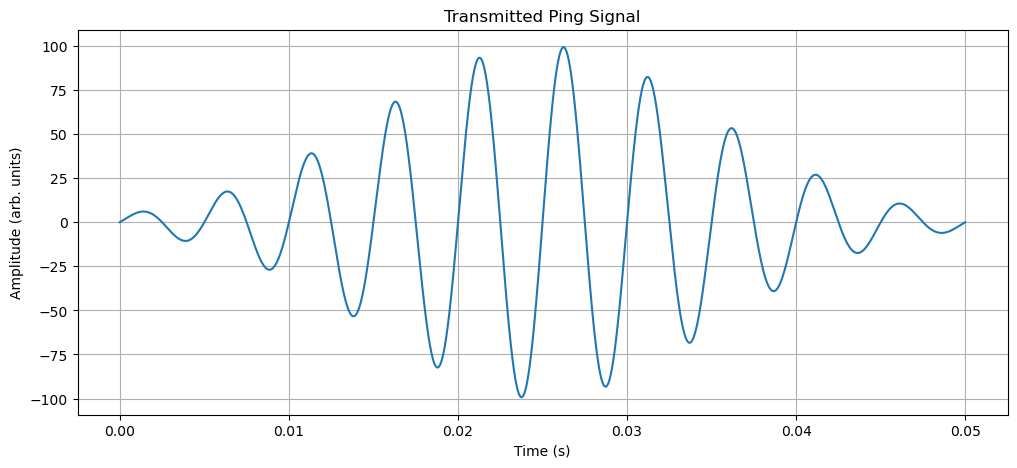

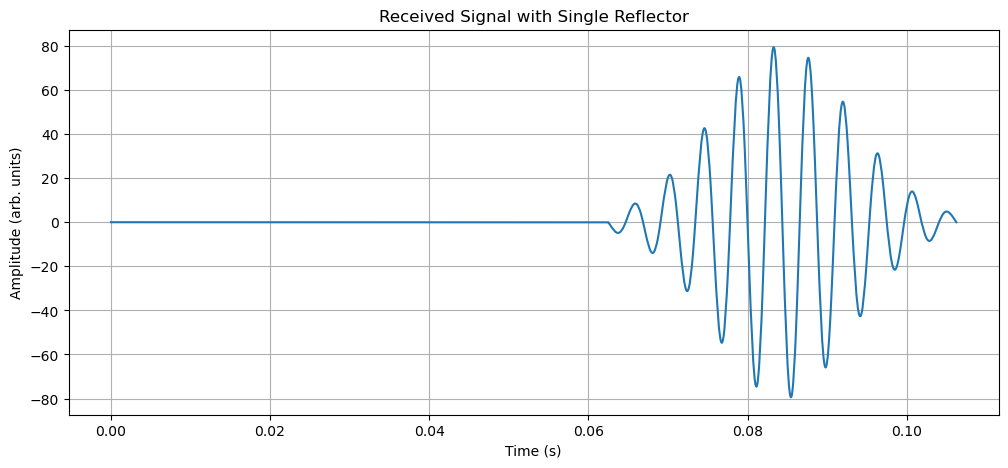

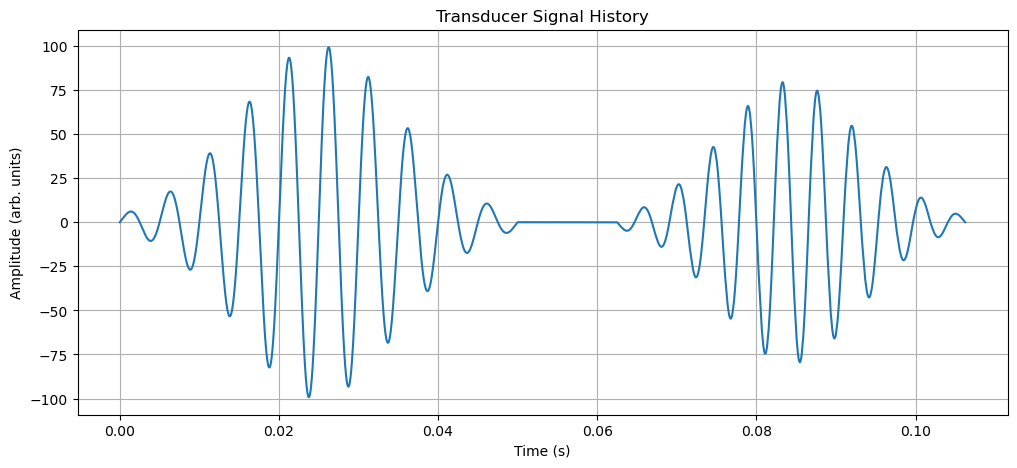

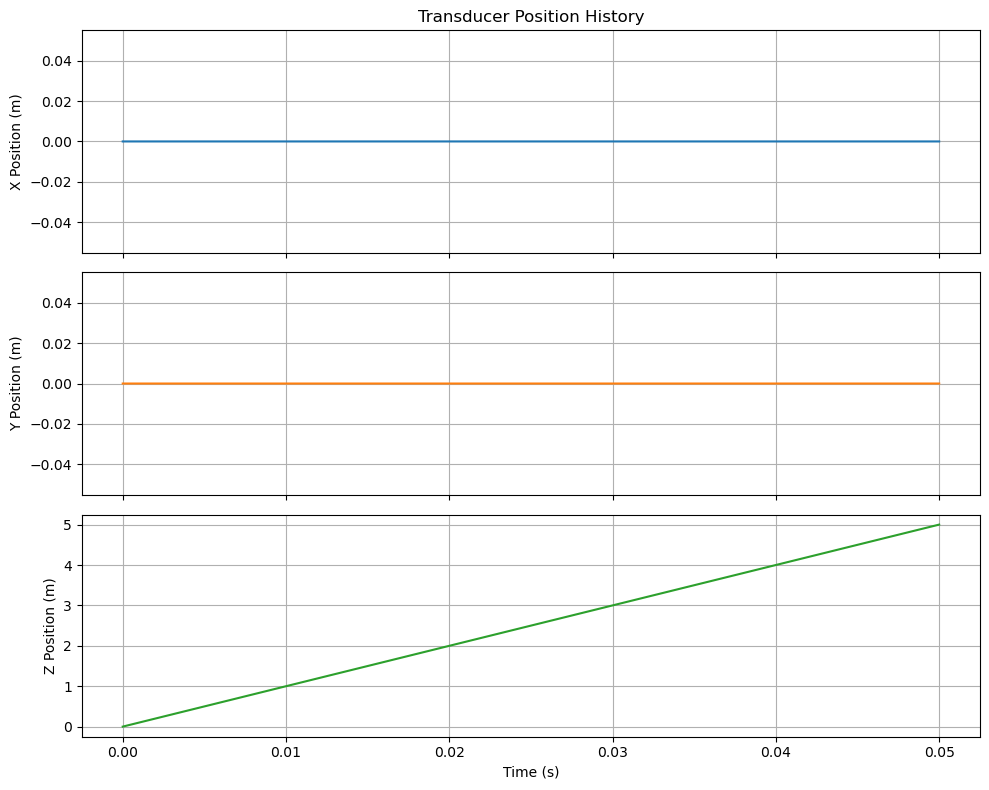

In [34]:
ping_object = Ping(
    frequency=2e2,
    n_cycles=10,
    duration=0.01,
    amplitude=100.0,
    phase=0,
    sample_rate=4e6,
    window_mode='gaussian'
)

transducer_object = Transducer(
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([0, 0, 100]),
    angle_deg=0.0,
    beam_width_deg=25.0
)

reflectors = [
    Reflector(
        position=np.array([0.0, 0.0, 100]),
        radius=50,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)




signal = ping_object.signal
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Transmitted Ping Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()


signal = transducer_object.receive_signal
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Received Signal with Single Reflector")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()


signal = transducer_object.transducer_history
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Transducer Signal History")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()

signal = transducer_object.ping_positions
time_axis = np.arange(len(signal)) / ping_object.fs

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# --- Plot X ---
ax1.plot(time_axis, signal[:, 0], color='tab:blue')
ax1.set_ylabel('X Position (m)')
ax1.set_title("Transducer Position History")
ax1.grid(True)

# --- Plot Y ---
ax2.plot(time_axis, signal[:, 1], color='tab:orange')
ax2.set_ylabel('Y Position (m)')
ax2.grid(True)

# --- Plot Z ---
ax3.plot(time_axis, signal[:, 2], color='tab:green')
ax3.set_ylabel('Z Position (m)')
ax3.set_xlabel("Time (s)")
ax3.grid(True)

plt.tight_layout()
plt.show()





# Stationary Case, Multi-Reflector 

Goals:
* Use frequency values closer to what we expect in the real world ~200kHz
* Verify multiple echoes from one transmitted signal due to reflection off multiple reflectors
* Verify function to measure the frequency of the transmitted and received signal


# Constant Velocity Directly towards/away Single Reflector 

Goals:
* Verify a stretched/compressed doppler shifted receive signal depending on the direction of travel (compressed if moving towards, streched if moving away)
* Measure the frequency shift and compare to expected double doppler shift
* Compute a velocity estimate and compare to expectations

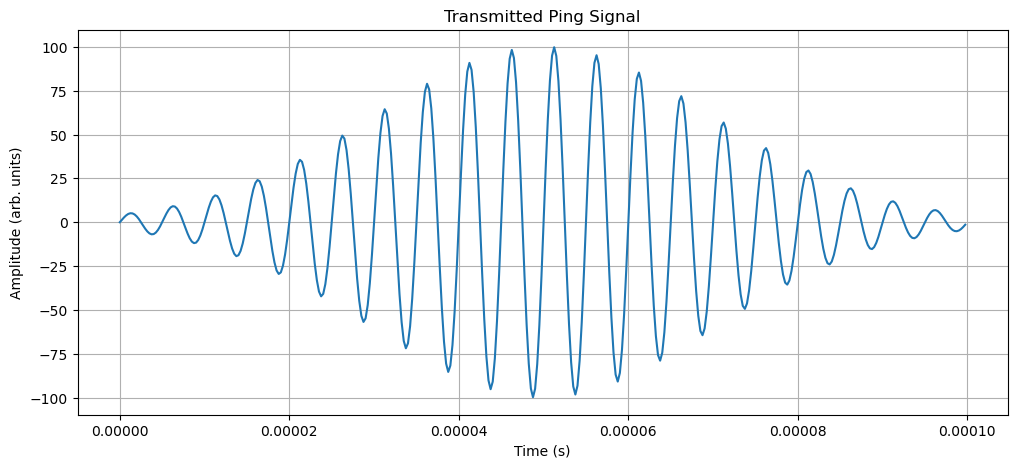

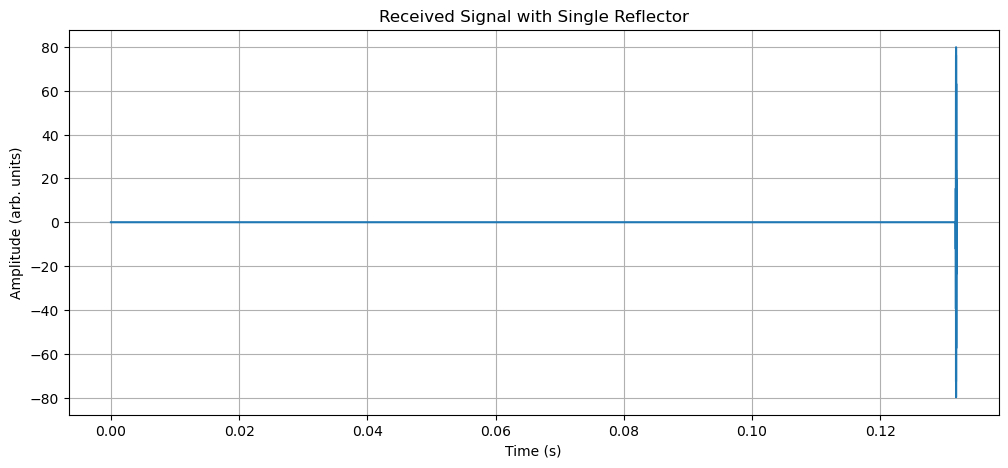

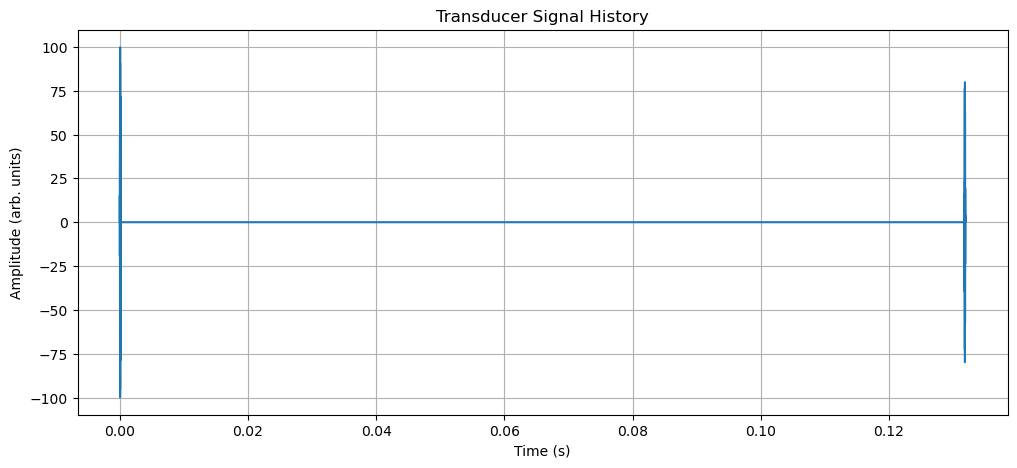

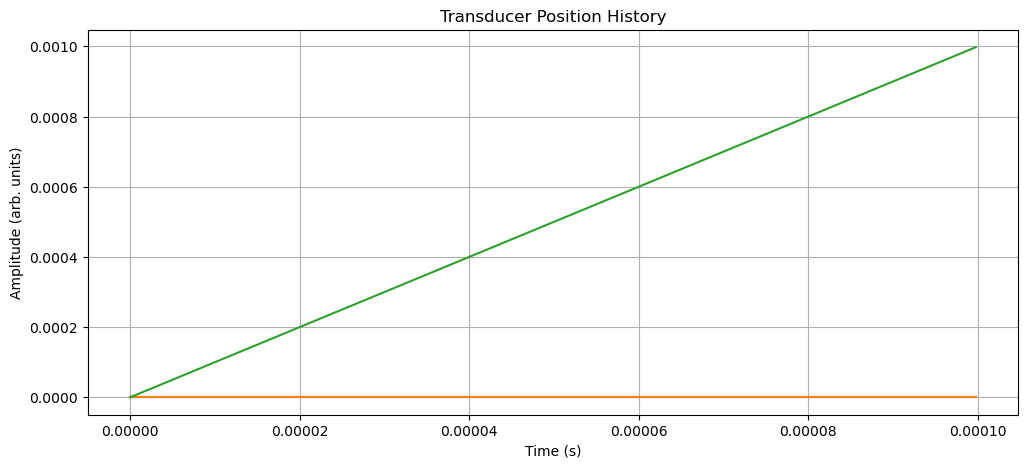

In [35]:
ping_object = Ping(
    frequency=200e3,
    n_cycles=20,
    amplitude=100.0,
    phase=0,
    sample_rate=4e6,
    window_mode='gaussian'
)

transducer_object = Transducer(
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([0, 0, 10]),
    angle_deg=0.0,
    beam_width_deg=25.0
)

reflectors = [
    Reflector(
        position=np.array([0.0, 0.0, 100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)

signal = ping_object.signal
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Transmitted Ping Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()


signal = transducer_object.receive_signal
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Received Signal with Single Reflector")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()


signal = transducer_object.transducer_history
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Transducer Signal History")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()

signal = transducer_object.ping_positions
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Transducer Position History")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()


In [36]:
peak_1, freqs_1, mag_1 = get_peak_frequency(ping_object.signal, ping_object.fs)
peak_2, freqs_2, mag_2 = get_peak_frequency(transducer_object.receive_signal, ping_object.fs)


separation_vec = reflectors[0].position - transducer_object.initial_position
dir = separation_vec / np.linalg.norm(separation_vec)
vel = np.dot(transducer_object.velocity, dir)
expected_doppler_shift = (2*ping_object.frequency*vel/World.c) + ping_object.frequency

print(f"Expected Doppler Shift Frequency: {expected_doppler_shift[0]:.2f} Hz")
print(f"Transmit Signal Peak Frequency: {peak_1:.2f} Hz")
print(f"Receive Signal Peak Frequency: {peak_2:.2f} Hz")

# plt.plot(freqs_1, mag_1, label='Transmit Signal Spectrum')
# plt.plot(freqs_2, mag_2, label='Receive Signal Spectrum')

Expected Doppler Shift Frequency: 202666.67 Hz
Transmit Signal Peak Frequency: 199985.90 Hz
Receive Signal Peak Frequency: 202668.34 Hz


# Constant Velocity at an Angle wrt Single Reflector 

Goals:
* Verify only the velcity component towards the reflector causes a frequency shift and compare to expected double doppler shift
* Compute a velocity estimate and compare to expectations

In [48]:
ping_object = Ping(
    frequency=200e3,
    n_cycles=20,
    amplitude=100.0,
    phase=0,
    sample_rate=4e6,
    window_mode='gaussian'
)

transducer_object = Transducer(
    position=np.array([0.0, 0.0, 0.0]),
    velocity=np.array([10, 5, 10]),
    angle_deg=0.0,
    beam_width_deg=25.0
)

reflectors = [
    Reflector(
        position=np.array([0.0, 0.0, 100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)

In [49]:
peak_1, freqs_1, mag_1 = get_peak_frequency(ping_object.signal, ping_object.fs)
peak_2, freqs_2, mag_2 = get_peak_frequency(transducer_object.receive_signal, ping_object.fs)


separation_vec = reflectors[0].position - transducer_object.initial_position
dir = separation_vec / np.linalg.norm(separation_vec)
vel = np.dot(transducer_object.velocity, dir)
expected_doppler_shift = (2*ping_object.frequency*vel/World.c) + ping_object.frequency

print(f"Angle of Motion: {np.degrees(np.arccos(vel / np.linalg.norm(transducer_object.velocity))):.2f} degrees")
print(f"Expected Doppler Shift Frequency: {expected_doppler_shift[0]:.2f} Hz")
print(f"Transmit Signal Peak Frequency: {peak_1:.2f} Hz")
print(f"Receive Signal Peak Frequency: {peak_2:.2f} Hz")

# plt.plot(freqs_1, mag_1, label='Transmit Signal Spectrum')
# plt.plot(freqs_2, mag_2, label='Receive Signal Spectrum')

Angle of Motion: 48.19 degrees
Expected Doppler Shift Frequency: 202666.67 Hz
Transmit Signal Peak Frequency: 199985.90 Hz
Receive Signal Peak Frequency: 202638.02 Hz


# Constant Velocity, Multiple Reflectors

Goals:
* Verify that only the reflectors in the transducer's beam angle are able to reflect the transmitted signal

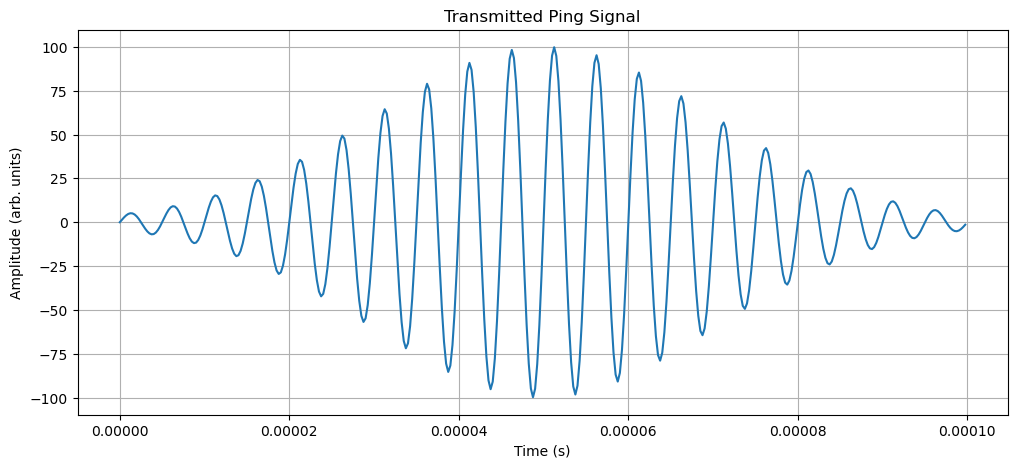

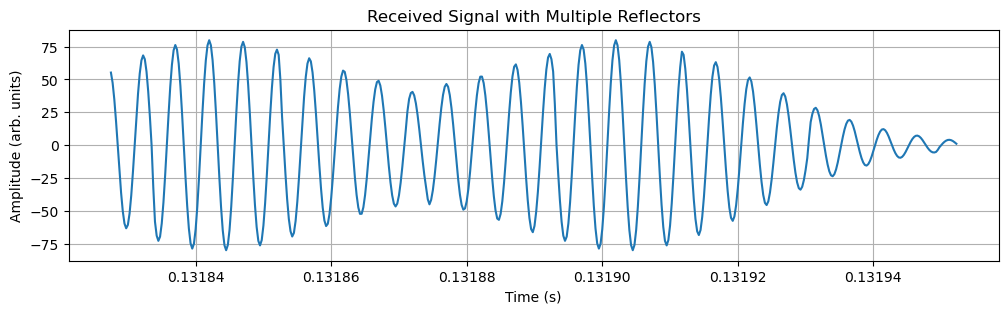

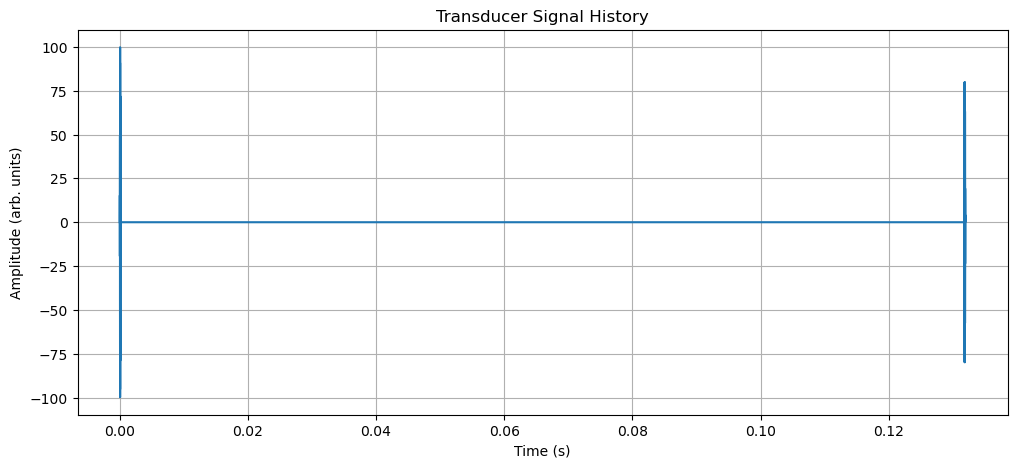

In [39]:
reflectors = [
    Reflector(
        position=np.array([0.0, 0.0, 100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
    Reflector(
        position=np.array([0.0, 3, 100]),
        radius=0.5,
        reflectivity=0.8,
        phase_shift_deg=180.0
    ),
    # Reflector(
    #     position=np.array([-5, 0, 15]),
    #     radius=2,
    #     reflectivity=0.8,
    #     phase_shift_deg=180.0
    # ),
    # Reflector(
    #     position=np.array([5, 5, 20]),
    #     radius=1,
    #     reflectivity=0.8,
    #     phase_shift_deg=180.0
    # ),
]

simulated_world = World(
    transducer=transducer_object,
    reflectors=reflectors,
)

simulated_world.run_simulation(ping_object)

signal = ping_object.signal
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Transmitted Ping Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()


signal = transducer_object.receive_signal
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 3))
plt.plot(time_axis[-500:], signal[-500:])
plt.title("Received Signal with Multiple Reflectors")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()


signal = transducer_object.transducer_history
time_axis = np.arange(len(signal)) / ping_object.fs

plt.figure(figsize=(12, 5))
plt.plot(time_axis, signal)
plt.title("Transducer Signal History")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (arb. units)")
plt.grid()
plt.show()
